In [29]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
import importlib
# add Modeling/ to Python path
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
import Modeling
importlib.reload(Modeling)
from Modeling.models.plotting import animate_field_1d
from Modeling.models.beam_properties import PiezoBeamParams
from Modeling.models import FE_helpers 
importlib.reload(FE_helpers)
import matplotlib.pyplot as plt
# from Modeling.models.ROM import ROM

import Modeling.models.FE3 as FE_module
importlib.reload(FE_module)
FE = FE_module
# import Modeling.models.ROM as ROM_module
# importlib.reload(ROM_module)
# ROM = ROM_module.ROM

# from FE1 import PiezoBeamFE, frf_sweep, solve_newmark
import numpy as np
from numpy import pi	
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from IPython.display import clear_output
from matplotlib import cm, colors
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

In [30]:

#%%

K_i = 0; K_p = 0.03; K_c = 0
t_end = 1
f0 = 1000; f1 = 6000
j_exc = 30

def v_exc(t, A_exc=50, f0=f0, f1=f1, t_end=t_end):
	return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)
params = PiezoBeamParams()
params.zeta_p = 0.0151*8
params.zeta_q = 0.0392*10
interface_idx = 18
beta = 0.3
# # ======= K_p sweep in frequency domain =======
ki0 = 4000
ki1 = ki0 / (1 - beta)**2 
ki2 = ki0 / (1 + beta)**2 
K_i = np.array([ki1, ki2] *(interface_idx//2) + [ki2, ki1] *(15-interface_idx//2) + [ki2])

np.set_printoptions(precision=0, suppress=True)
print("K_i:", K_i, )


K_i: [8163. 2367. 8163. 2367. 8163. 2367. 8163. 2367. 8163. 2367. 8163. 2367.
 8163. 2367. 8163. 2367. 8163. 2367. 2367. 8163. 2367. 8163. 2367. 8163.
 2367. 8163. 2367. 8163. 2367. 8163. 2367.]


In [31]:
FRF.shape

(2000, 157)

In [38]:
fe.todict()

AttributeError: 'PiezoBeamFE' object has no attribute 'todict'

First 5 natural frequencies (FE): [  5.  33.  93. 183. 302.] Hz
alpha, beta 5.779324762080678 1.1305134053258193e-07
Running time domain simulation with FE model...
Computing frequency response (FE)...


Newmark Integration: 100%|██████████| 120000/120000 [04:11<00:00, 477.92step/s]


X shape: (120001,) Y shape: (120001, 157) freq shape: (120001,) veloc shape: (120001, 157)
FE frequency response complete.


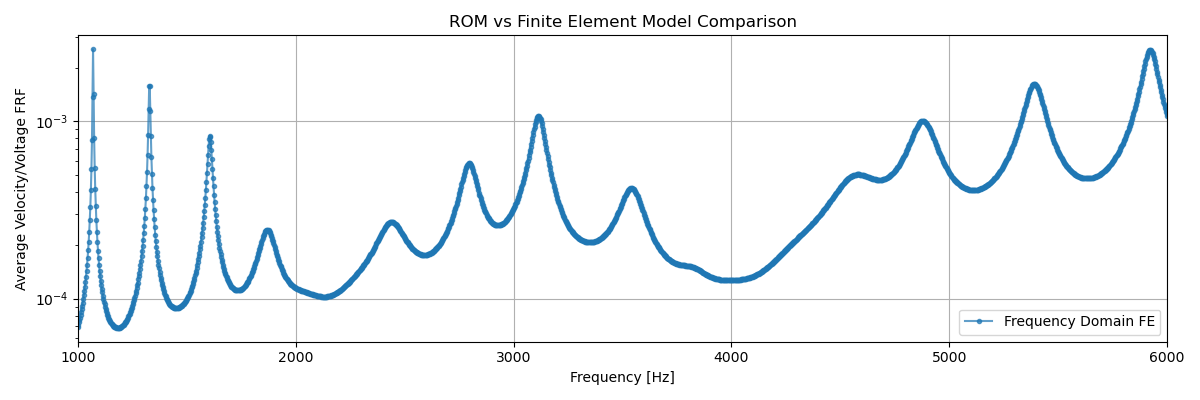

In [32]:
%matplotlib widget
# =================== Finite Element Analysis ===================
# Setup FE model with same parameters
params_fe = PiezoBeamParams()
params_fe.zeta_p = 0.0151
params_fe.zeta_q = 0.0392

# Create FE model
fe = FE.PiezoBeamFE(params_fe)

# Perform eigenanalysis
freq_fe, omega_fe, Phi_fe = fe.eigen_analysis()
print(f"First 5 natural frequencies (FE): {freq_fe[:5]} Hz")

K_i_mean = np.mean(K_i)
amp = 1
def v_exc(t):
    return amp * np.sin(
        2 * np.pi * (f0 + t * (f1 - f0) / t_end) * t
    )

ode_fe = fe.build_ode_system(
    j_exc=30,
    K_c=0,
    K_i=K_i,
    K_p=K_p,
    R_c=1e3,
    v_exc=v_exc
)

# =================== Time Domain Simulation (FE) ===================
print("Running time domain simulation with FE model...")
dt = 1/(f1*20)
# t_fe, x_fe, x_dot_fe, x_ddot_fe = solve_newmark(
#     ode_fe,
#     dt=dt,
#     t_end=t_end,
#     beta=0.25,
#     gamma=0.5,
#     newton_tol=1e-9,
#     newton_maxiter=5
# )

# # Extract mechanical DOFs (displacement)
N_mech = ode_fe.N_mech


# =================== Frequency Domain Analysis (FE) ===================
print("Computing frequency response (FE)...")
omega_sweep = np.linspace(f0, f1, 2000) * 2 * np.pi
sweep_fe = FE_helpers.frf_sweep(ode_fe, omega_sweep)


# Extract mechanical response

FRF = sweep_fe['u_dot']
freq = sweep_fe['freq']
ndof = ode_fe.M.shape[0]
result = FE_helpers.solve_newmark(
    ode=ode_fe,
    dt=dt,
    t_end=t_end,
    beta=0.25,
    gamma=0.5,
    newton_tol=1e-8,
    newton_maxiter=8,
    x0=np.zeros(ndof),
    x_dot0=np.zeros(ndof)
)


fe_time_domain = {
    "t": result['t'],
    "displacement": result['u'],
    "velocity": result['spectral']['Y'],
    'frf': np.abs(result['spectral']['FRF']),
    'freq': result['spectral']['freq']
}
print("FE frequency response complete.")

# =================== Plot Comparison: ROM vs FE ===================
plt.figure(figsize=(12, 4))
plt.semilogy(freq, np.mean(np.abs(FRF), axis=1), '.-', linewidth=1.5, label='Frequency Domain FE', alpha=0.7)
# plt.semilogy(freq_modal, vel_mag, '.-', label='Frequency Domain ROM')
# plt.semilogy(freq_fft_fe_pos, V_mag_fe, 's-', linewidth=1.5, markersize=3, label='Time Domain FE', alpha=0.7)
# plt.semilogy(freq_sweep_fe, vel_mag_fe, 'o-', markersize=3, label='Frequency Domain FE', alpha=0.7)
plt.legend()
plt.xlim([f0, f1])
plt.xlabel("Frequency [Hz]")
plt.ylabel("Average Velocity/Voltage FRF")
plt.title("ROM vs Finite Element Model Comparison")
plt.grid(True)
plt.tight_layout()
plt.show()


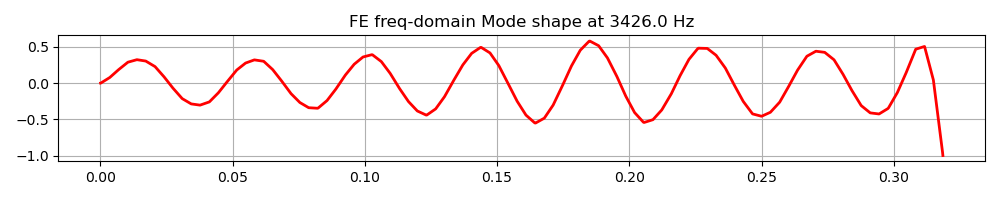

ki0=  4000 beta=  0.3 f_target=  3426.0


In [33]:
f_target = 3426.0  # Hz
x_coords_fe = fe.geom.x_nodes[1:]

# If FE FRF sweep exists, sample nearest; otherwise compute single-frequency FRF
idx_near = np.argmin(np.abs(freq - f_target))
w_hat_nodes = FRF[idx_near, :]  # displacement at reduced nodes (complex)
omega_t = 2*np.pi*freq[idx_near]
v_plot = np.abs(w_hat_nodes) * np.where((np.angle(w_hat_nodes)>=-np.pi/2) & (np.angle(w_hat_nodes)<=np.pi/2), 1, -1)
v_plot = np.imag(w_hat_nodes) 
max_abs = np.max(np.abs(v_plot))
if max_abs > 0:
    v_plot = v_plot / max_abs

plt.figure(figsize=(10, 2))
plt.plot(x_coords_fe, v_plot, 'r-', linewidth=2)
# plt.xlabel('Position along beam [m]')
# plt.ylabel('Normalized velocity (real)')
plt.title(f'FE freq-domain Mode shape at {f_target:.1f} Hz')
plt.grid(True)
plt.tight_layout()
plt.show()
print("ki0= ", ki0, 'beta= ', beta, 'f_target= ', f_target)

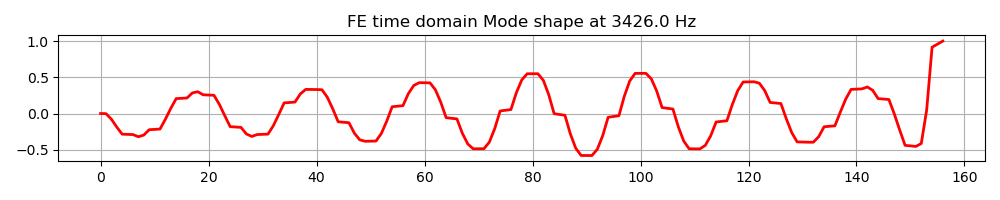

ki0=  4000 beta=  0.3 f_target=  3426.0


In [ ]:
f_target = 3426.0  # Hz
x_coords_fe = fe.geom.x_nodes[1:]
freq_td = result['spectral']['freq']
# If FE FRF sweep exists, sample nearest; otherwise compute single-frequency FRF
idx_near = np.argmin(np.abs(freq_td - f_target))
w_hat_nodes = result['spectral']['Y'][idx_near, :]  # displacement at reduced nodes (complex)
omega_t = 2*np.pi*freq_td[idx_near]
v_plot = np.abs(w_hat_nodes) * np.where((np.angle(w_hat_nodes)>=-np.pi/2) & (np.angle(w_hat_nodes)<=np.pi/2), 1, -1)
v_plot = np.imag(w_hat_nodes) 
max_abs = np.max(np.abs(v_plot))
if max_abs > 0:
    v_plot = v_plot / max_abs

plt.figure(figsize=(10, 2))
plt.plot(x_coords_fe, v_plot, 'r-', linewidth=2)
# plt.xlabel('Position along beam [m]')
# plt.ylabel('Normalized velocity (real)')
plt.title(f'FE time domain Mode shape at {f_target:.1f} Hz')
plt.grid(True)
plt.tight_layout()
plt.show()
print("ki0= ", ki0, 'beta= ', beta, 'f_target= ', f_target)

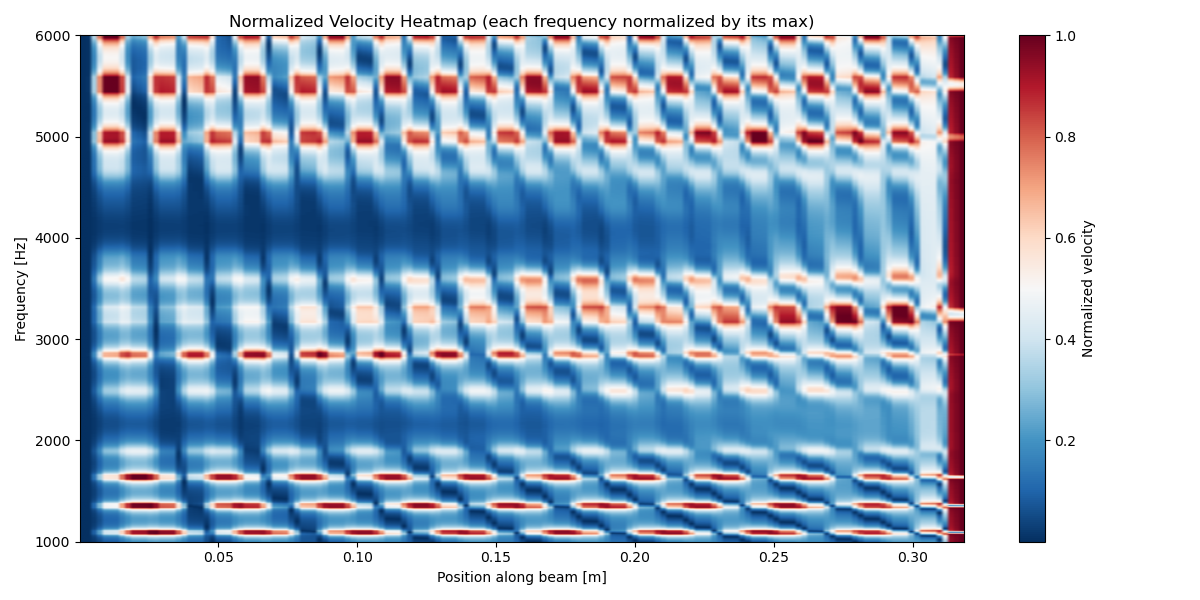

In [35]:
# Heatmap: normalized velocity for all frequencies
omega_all = 2*np.pi*freq
# v_hat_all = 1j * omega_all[:, np.newaxis] * FRF  # shape: (n_freq, n_nodes)
v_plot_all = np.abs(FRF)

# Normalize each frequency by its own maximum
v_plot_normalized = np.zeros_like(v_plot_all)
for i in range(v_plot_all.shape[0]):
    max_abs_i = np.max(np.abs(v_plot_all[i, :]))
    if max_abs_i > 0:
        v_plot_normalized[i, :] = v_plot_all[i, :] / max_abs_i

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(v_plot_normalized, aspect='auto', origin='lower', cmap='RdBu_r', 
               extent=[x_coords_fe[0], x_coords_fe[-1], freq[0], freq[-1]])
ax.set_xlabel('Position along beam [m]')
ax.set_ylabel('Frequency [Hz]')
ax.set_title('Normalized Velocity Heatmap (each frequency normalized by its max)')
cbar = plt.colorbar(im, ax=ax, label='Normalized velocity')
plt.tight_layout()
plt.show()